# 03 — SHAP Explainability

**Why** did the model flag a connection as an attack? SHAP answers this.

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/network_data.csv')
le = LabelEncoder()
df['protocol_encoded'] = le.fit_transform(df['protocol_type'])

FEATURES = ['duration','src_bytes','dst_bytes','count','srv_count',
            'same_srv_rate','diff_srv_rate','dst_host_count','dst_host_srv_count','protocol_encoded']

X = df[FEATURES]
y = (df['label']=='attack').astype(int)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print('Model ready.')

Model ready.


In [7]:
# SHAP TreeExplainer
explainer = shap.TreeExplainer(rf)
X_test_df = pd.DataFrame(X_test, columns=FEATURES)
shap_values = explainer.shap_values(X_test_df)
print(f'SHAP values shape: {np.array(shap_values).shape}')

SHAP values shape: (200, 10, 2)


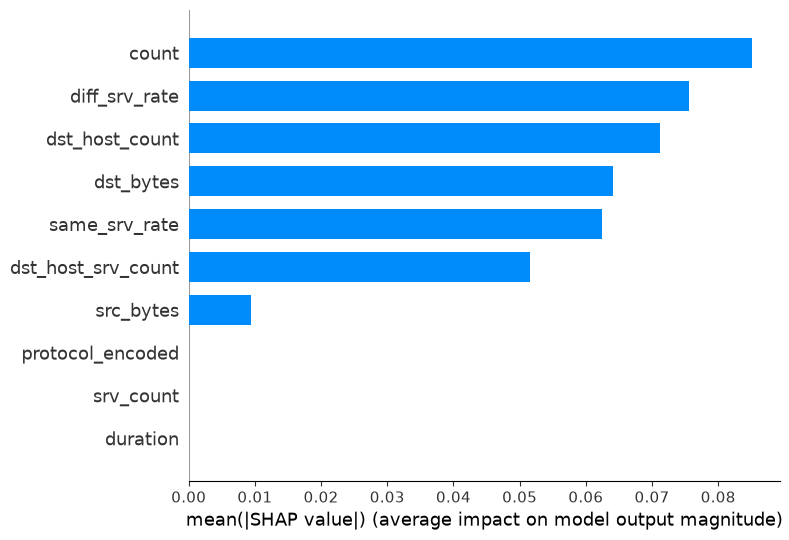

In [8]:
# Summary plot — what features matter most overall?
shap.summary_plot(shap_values[:, :, 1], X_test_df, plot_type='bar', show=True)

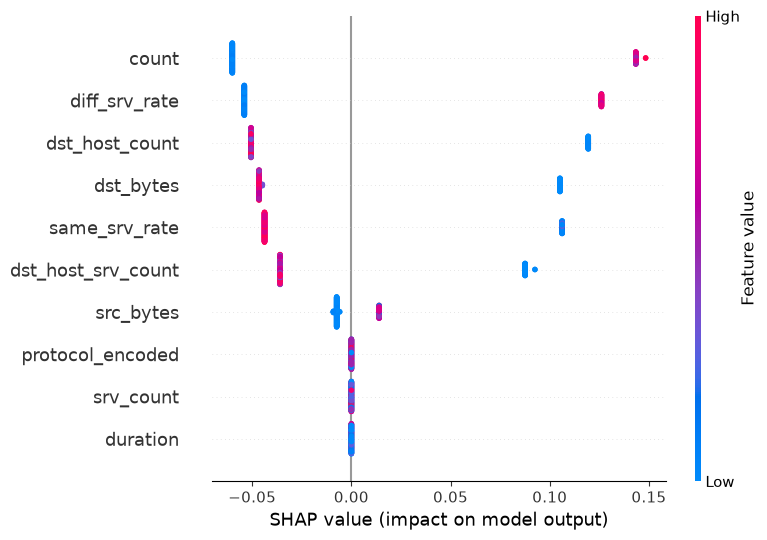

In [9]:
# Beeswarm — how feature values push prediction
shap.summary_plot(shap_values[:, :, 1], X_test_df, show=True)

Explaining sample 2 (actual: attack)


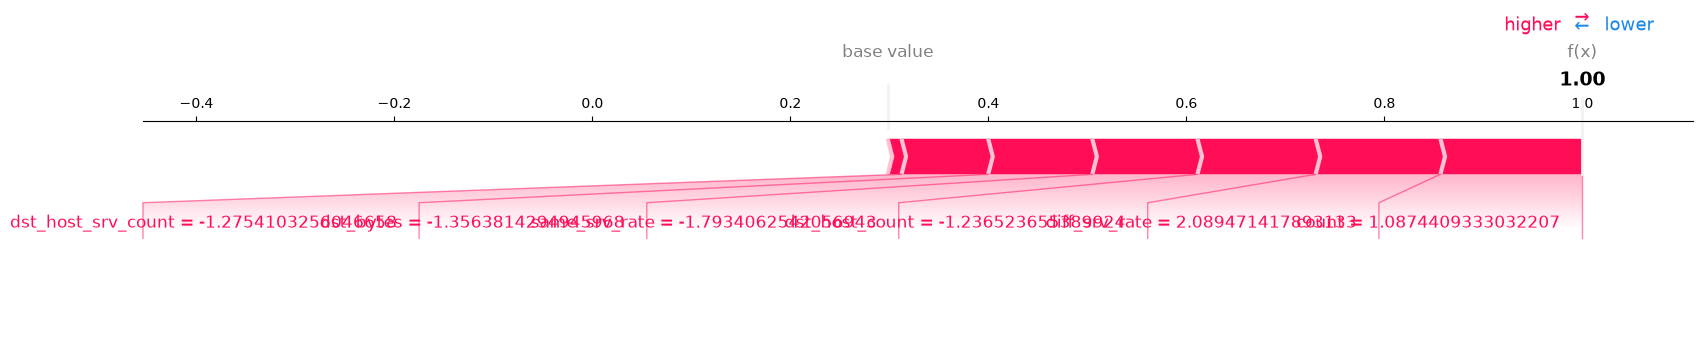

In [10]:
# Single prediction explanation — pick an attack sample
attack_idx = np.where(y_test == 1)[0][0]
print(f'Explaining sample {attack_idx} (actual: attack)')
shap.force_plot(explainer.expected_value[1], shap_values[attack_idx, :, 1], X_test_df.iloc[attack_idx], matplotlib=True)

## What SHAP Tells Us

- **`src_bytes`** is the single strongest predictor — attackers send huge volumes of data
- **`count`** (connections per second) is the second strongest — port scan / flood indicators  
- **`diff_srv_rate`** catches lateral movement (connecting to many services)
- SHAP lets us **explain any individual prediction** — critical for security tooling where you need to justify flagging a connection